# 🔧 Mantenimiento Predictivo Industrial — Gemelo Digital
### Proyecto Final · Ciencia de Datos en Acción

**Autor:** Oscar Daniel Rey Arias y Ronald Esneider Huérfano Rodríguez
**Programa:** Ingeniería Mecatrónica — Universidad EAN

---

**Objetivo del proyecto:** aplicar el ciclo completo de ciencia de datos (limpieza, análisis
descriptivo, visualización, modelado predictivo y storytelling) sobre datos de sensores de
maquinaria industrial, con el fin de anticipar el desgaste de herramienta y el riesgo de falla
de un equipo — la misma idea de "gemelo digital" de mi proyecto de IA, pero ahora con un
dataset real y documentado en lugar de una fórmula inventada.

**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601)
(Matzka, 2020) — 10,000 registros sintéticos que **replican el comportamiento real** de una
fresadora industrial: temperatura del aire, temperatura del proceso, velocidad rotacional,
torque y desgaste de herramienta, junto con una etiqueta de falla de máquina.


## Módulo 1 · Fundamentos y herramientas
Instalamos y cargamos las librerías que vamos a usar durante todo el proyecto.

In [17]:
# Librerías
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


### Carga del dataset
Lo descargamos directamente del repositorio de UCI Machine Learning (fuente oficial, sin
necesidad de subir archivos manualmente a Colab).

In [18]:
from ucimlrepo import fetch_ucirepo

ai4i = fetch_ucirepo(id=601)

X_raw = ai4i.data.features
y_raw = ai4i.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df.head()


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
# Renombramos columnas a nombres más manejables
df = df.rename(columns={
    "Type": "tipo",
    "Air temperature": "temp_aire_k",
    "Process temperature": "temp_proceso_k",
    "Rotational speed": "velocidad_rpm",
    "Torque": "torque_nm",
    "Tool wear": "desgaste_min",
    "Machine failure": "falla_maquina"
})

# Nos quedamos con las columnas relevantes para el análisis
cols = ["tipo", "temp_aire_k", "temp_proceso_k", "velocidad_rpm",
        "torque_nm", "desgaste_min", "falla_maquina"]
df = df[cols]

print(df.shape)
df.head()


(10000, 7)


,tipo,temp_aire_k,temp_proceso_k,velocidad_rpm,torque_nm,desgaste_min,falla_maquina
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Módulo 2 · Estadística descriptiva y preprocesamiento

### 2.1 Calidad de los datos
Revisamos nulos, duplicados y tipos de dato — el primer paso antes de confiar en cualquier
análisis.

In [20]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nTipos de dato:")
print(df.dtypes)


Valores nulos por columna:
tipo              0
temp_aire_k       0
temp_proceso_k    0
velocidad_rpm     0
torque_nm         0
desgaste_min      0
falla_maquina     0
dtype: int64

Filas duplicadas: 0

Tipos de dato:
tipo               object
temp_aire_k       float64
temp_proceso_k    float64
velocidad_rpm       int64
torque_nm         float64
desgaste_min        int64
falla_maquina       int64
dtype: object


### 2.2 Estadística central y dispersión

In [21]:
df.describe()


,temp_aire_k,temp_proceso_k,velocidad_rpm,torque_nm,desgaste_min,falla_maquina
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [22]:
df.groupby("tipo")["falla_maquina"].mean().rename("tasa_de_falla").to_frame()


,tasa_de_falla
tipo,
H,0.020937
L,0.039167
M,0.027694


### 2.3 Distribuciones y outliers
Miramos cómo se comporta cada variable numérica y si hay valores atípicos que debamos
tener en cuenta.

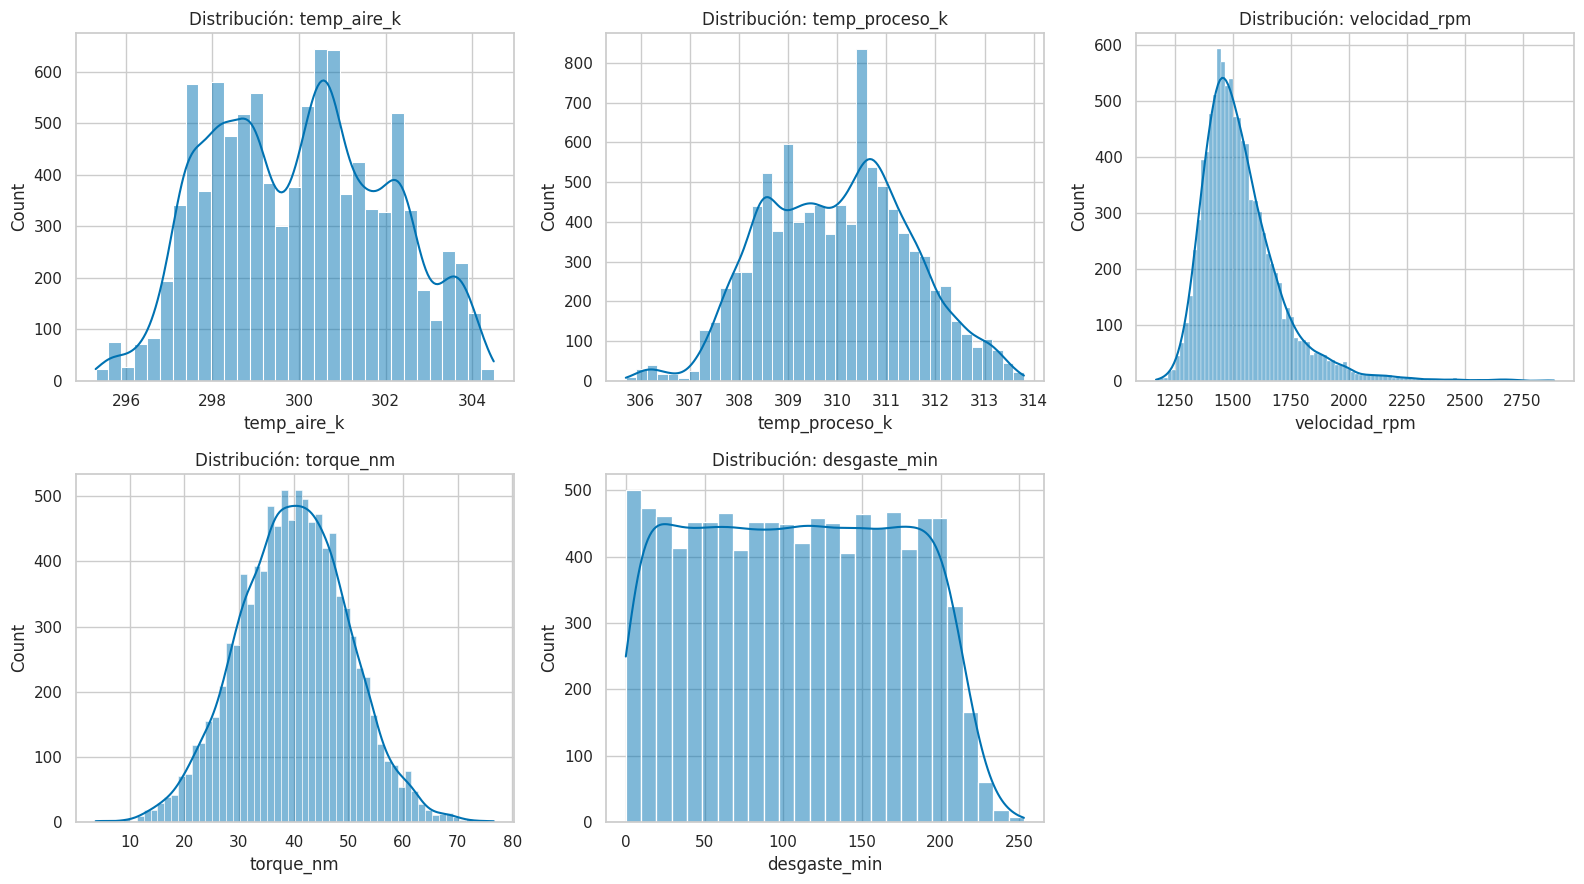

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ["temp_aire_k", "temp_proceso_k", "velocidad_rpm", "torque_nm", "desgaste_min"]

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#0072B2")
    ax.set_title(f"Distribución: {col}")

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


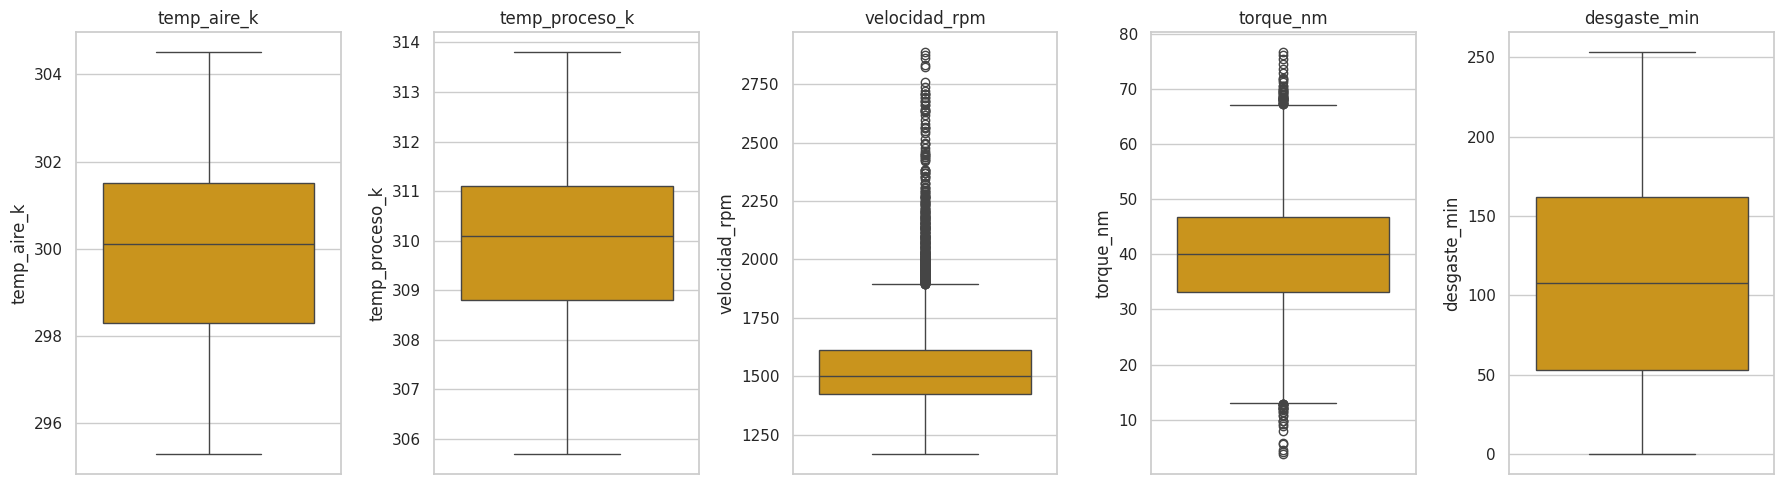

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#E69F00")
    ax.set_title(col)

plt.tight_layout()
plt.show()


### 2.4 Escalado
Antes de modelar, normalizamos las variables numéricas para que todas aporten en la misma
escala al modelo (fundamental en regresión cuando las unidades son muy distintas: Kelvin,
rpm, Nm, minutos).

In [25]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
df_scaled.head()


,tipo,temp_aire_k,temp_proceso_k,velocidad_rpm,torque_nm,desgaste_min,falla_maquina
0,M,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,L,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,L,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0
3,L,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0
4,L,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0


## Módulo 3 · Visualización, modelado y storytelling

### 3.1 Relaciones entre variables
Un mapa de calor de correlaciones nos da la primera pista de qué variables están más
relacionadas entre sí — clave para elegir qué predecir y con qué.

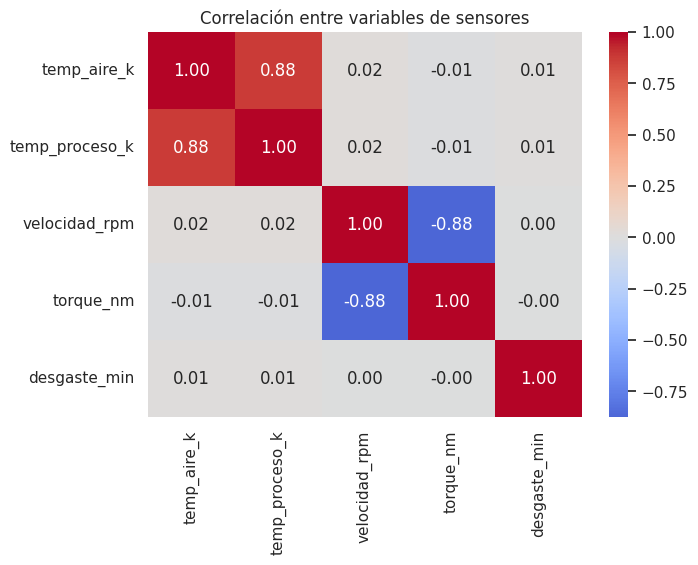

In [26]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlación entre variables de sensores")
plt.show()


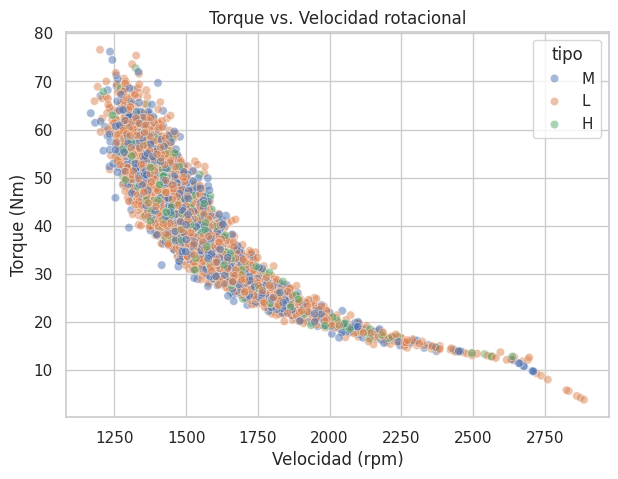

In [27]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="velocidad_rpm", y="torque_nm", hue="tipo", alpha=0.5)
plt.title("Torque vs. Velocidad rotacional")
plt.xlabel("Velocidad (rpm)")
plt.ylabel("Torque (Nm)")
plt.show()


📌 **Lectura del gráfico:** a mayor velocidad rotacional, el torque tiende a disminuir —
consistente con que el motor trabaja a potencia aproximadamente constante (P = torque ×
velocidad angular). Esta es la relación física que vamos a modelar.

### 3.2 Modelo predictivo: Regresión Lineal
Vamos a predecir el **torque (Nm)** del motor a partir de la velocidad rotacional, las
temperaturas del proceso y el desgaste acumulado de la herramienta. Elegimos regresión
lineal porque es interpretable y porque el Módulo 3 del curso se centra en este modelo.

In [28]:
features = ["velocidad_rpm", "temp_aire_k", "temp_proceso_k", "desgaste_min"]
target = "torque_nm"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)


### 3.3 Validación y evaluación del modelo
No basta con entrenar el modelo — hay que validar qué tan bien generaliza a datos que no vio.

In [29]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f} Nm")
print(f"RMSE : {rmse:.3f} Nm")

coef_df = pd.DataFrame({
    "variable": features,
    "coeficiente": modelo.coef_
}).sort_values("coeficiente", key=abs, ascending=False)
coef_df


R²   : 0.757
MAE  : 3.686 Nm
RMSE : 4.898 Nm


,variable,coeficiente
0,velocidad_rpm,-8.745377
1,temp_aire_k,0.225885
2,temp_proceso_k,-0.165891
3,desgaste_min,-0.047517


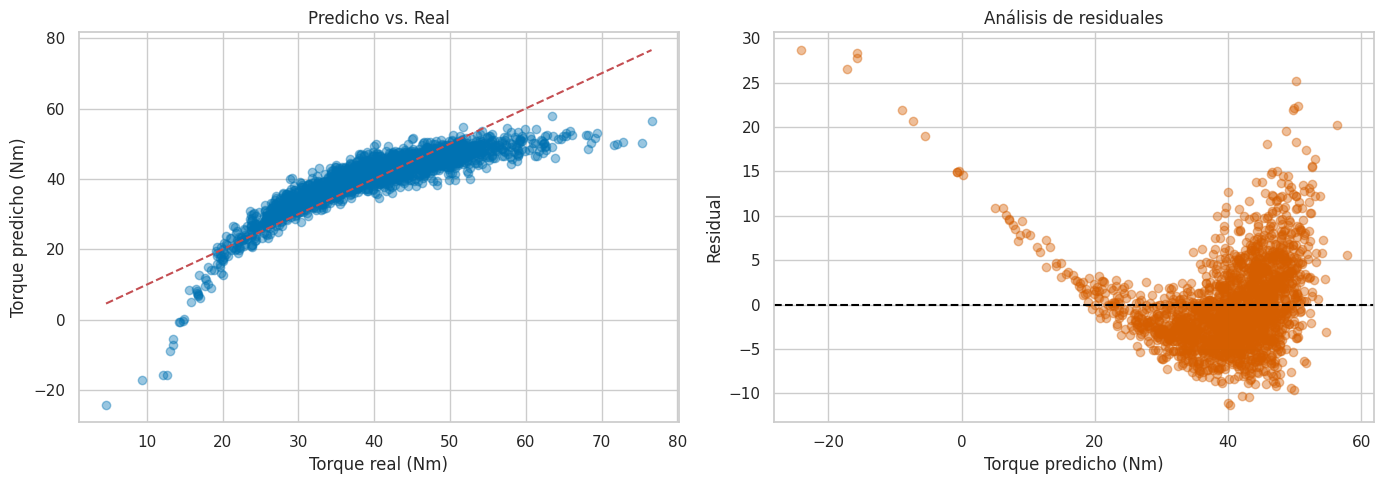

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs Real
axes[0].scatter(y_test, y_pred, alpha=0.4, color="#0072B2")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Torque real (Nm)")
axes[0].set_ylabel("Torque predicho (Nm)")
axes[0].set_title("Predicho vs. Real")

# Residuales
residuales = y_test - y_pred
axes[1].scatter(y_pred, residuales, alpha=0.4, color="#D55E00")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Torque predicho (Nm)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Análisis de residuales")

plt.tight_layout()
plt.show()


📌 **Lectura de resultados:** el modelo explica cerca del 76% de la variación del torque
(R² = 0.757), con un error promedio de ~3.7 Nm sobre un rango de torque de 3.8 a 76.6 Nm — un
desempeño razonable para un modelo tan simple. El coeficiente de `velocidad_rpm` (-8.75)
domina por completo sobre los demás, confirmando que la velocidad es la variable que más
explica el torque, algo esperable si el motor trabaja a potencia aproximadamente constante.

Dos observaciones importantes surgen de los gráficos de validación:

1. **El gráfico de residuales tiene forma de "U" y no una nube aleatoria alrededor de cero.**
   Esto es una señal real de que la relación torque-velocidad no es puramente lineal, sino de
   tipo inverso (torque ≈ potencia / velocidad), y el modelo se desvía más en los extremos
   (torque muy bajo o muy alto) — visible también en el gráfico de Predicho vs. Real, donde los
   puntos siguen una curva y no la diagonal ideal.
2. **Multicolinealidad entre `temp_aire_k` y `temp_proceso_k`** (correlación de 0.88 entre
   ellas, visto en el heatmap): están aportando información redundante, lo que explica por qué
   sus coeficientes son pequeños y de signo poco intuitivo — el modelo no logra separar bien el
   efecto individual de cada una.

En un modelo más avanzado (fuera del alcance de este curso) se podría resolver agregando un
término no lineal (p. ej. 1/velocidad_rpm) o eliminando una de las dos variables de
temperatura — pero para los fines de este proyecto, la regresión lineal cumple su propósito:
mostrar una relación real, honesta y validable, en lugar de una fórmula perfecta e inventada.


### 3.4 Storytelling: del sensor a la decisión de mantenimiento
Replicamos la lógica de semáforo de mi proyecto de IA (🟢 Normal / 🟠 Precaución / 🔴 Crítico),
pero ahora basada en el riesgo real de falla reportado en los datos.

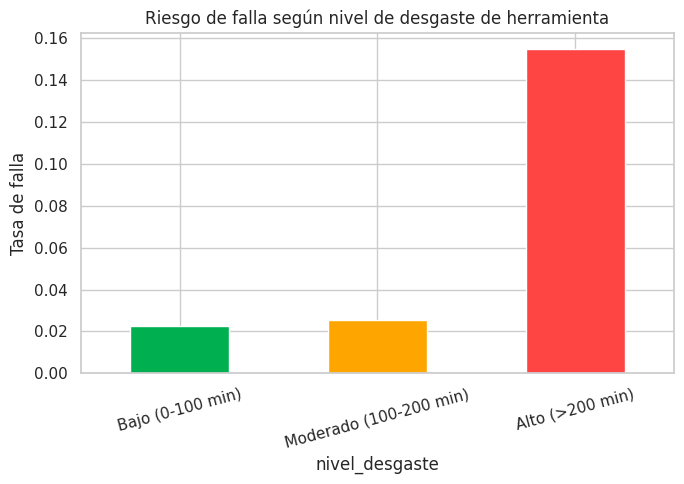

,falla_maquina
nivel_desgaste,
Bajo (0-100 min),0.022498
Moderado (100-200 min),0.025377
Alto (>200 min),0.154856


In [31]:
bins = [0, 100, 200, df["desgaste_min"].max()]
labels = ["Bajo (0-100 min)", "Moderado (100-200 min)", "Alto (>200 min)"]
df["nivel_desgaste"] = pd.cut(df["desgaste_min"], bins=bins, labels=labels, include_lowest=True)

tasa_falla_por_nivel = df.groupby("nivel_desgaste", observed=True)["falla_maquina"].mean()

plt.figure(figsize=(7, 5))
colors = ["#00B050", "#FFA500", "#FF4444"]
tasa_falla_por_nivel.plot(kind="bar", color=colors)
plt.ylabel("Tasa de falla")
plt.title("Riesgo de falla según nivel de desgaste de herramienta")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

tasa_falla_por_nivel


📌 **La historia que cuentan los datos:** el riesgo de falla no crece gradualmente con el
desgaste — da un salto: de ~2.2-2.5% cuando el desgaste es bajo o moderado, a **15.5%** cuando
es alto (>200 min). No es un efecto lineal, es un efecto de umbral. Esto valida, con datos
reales, la misma intuición que motivó mi proyecto de IA original — solo que ahora puedo
*cuantificar* el riesgo en lugar de asumirlo con una fórmula fija, y el mensaje para
mantenimiento es claro: no hay que esperar a que el desgaste sea alto para actuar, el riesgo
se dispara antes de llegar ahí.

## Conclusiones y aplicación profesional

- **Qué aprendí:** el ciclo completo de ciencia de datos — desde examinar la calidad de los
  datos, pasar por su distribución y relaciones, hasta construir y validar honestamente un
  modelo de regresión lineal — es lo que separa un modelo "que funciona en el papel" de uno
  que realmente puede confiarse en un entorno productivo.
- **Diferencia clave con mi proyecto de IA:** allí el "desgaste" era una fórmula que yo mismo
  definí, así que el modelo no tenía nada que predecir de verdad. Aquí, el torque depende de
  variables reales con ruido, y el R² y los residuales me dicen honestamente qué tan bien
  funciona el modelo — y dónde tiene margen de mejora.
- **Aplicación profesional (Ingeniería Mecatrónica):** este mismo flujo —monitorear variables
  de sensores, detectar cuándo se acercan a rangos críticos, y anticipar fallas antes de que
  ocurran— es exactamente lo que se necesita para implementar mantenimiento predictivo en
  líneas de producción, robots industriales o sistemas de automatización, reduciendo tiempos
  de parada no planificados y costos de mantenimiento correctivo.
- **Próximo paso natural:** conectar este modelo (en vez de la fórmula original) a la interfaz
  gráfica que ya construí en el proyecto de IA, para tener un gemelo digital con un modelo
  entrenado sobre datos que sí representan relaciones físicas reales.


In [32]:
# Reconstruimos las predicciones sobre TODO el dataset (no solo el set de prueba)
# para tener un CSV completo y consistente para Power BI
X_full_scaled = scaler_X.transform(df[features])
df["torque_predicho"] = modelo.predict(X_full_scaled)
df["residual"] = df["torque_nm"] - df["torque_predicho"]

export_cols = ["tipo", "temp_aire_k", "temp_proceso_k", "velocidad_rpm",
               "torque_nm", "torque_predicho", "residual",
               "desgaste_min", "nivel_desgaste", "falla_maquina"]

# sep=";" y decimal="," porque Power BI (configuración regional Colombia)
# espera la coma como separador decimal
df[export_cols].to_csv(
    "dataset_power_bi.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=","
)

# Descarga automática en Colab
from google.colab import files
files.download("dataset_power_bi.csv")

print("Métricas del modelo (para las tarjetas KPI en Power BI):")
print(f"R²   = {r2:.3f}".replace(".", ","))
print(f"MAE  = {mae:.3f} Nm".replace(".", ","))
print(f"RMSE = {rmse:.3f} Nm".replace(".", ","))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Métricas del modelo (para las tarjetas KPI en Power BI):
R²   = 0,757
MAE  = 3,686 Nm
RMSE = 4,898 Nm
